Exercise 1

In [1]:
import math, random, time, statistics
from MP2_exercise import estimate_pi_serial

if __name__ == '__main__':
    random.seed(42)
    num_samples = 10000000
    times = []
    pies = []
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
        pies.append(pi_estimate)
        print(f"Run {_+1}:")
        print(f"pi estimate: {pi_estimate:.6f}")
        print(f"error: {abs(pi_estimate - math.pi):.6f}")
        print(f"Time: {time.perf_counter() - t0:.3f} s")

    t_serial = statistics.median(times)
    print("averages:")
    print(f"pi estimate: {statistics.median(pies):.6f} (error: {abs(statistics.median(pies)-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")

Run 1:
pi estimate: 3.142310
error: 0.000717
Time: 1.040 s
Run 2:
pi estimate: 3.141866
error: 0.000273
Time: 1.060 s
Run 3:
pi estimate: 3.141505
error: 0.000087
Time: 1.039 s
averages:
pi estimate: 3.141866 (error: 0.000273)
Serial time: 1.040s


How accurate is the estimate? On average: 0.000273 with 3 runs and 10kk samples  
Run several times — does it vary? yes  
What is the serial time? 1.036seconds This will be your speedup denominator in E3.

In [2]:
from MP2_exercise import estimate_pi_parallel
import os, time, statistics, random

if __name__ == '__main__':
    random.seed(42)
    num_samples = 10_000_000
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            times.append(time.perf_counter() - t0)
        t = statistics.median(times)
        print(f"{num_proc:2d} workers: {t:.3f}s pi={pi_est:.6f}")

 1 workers: 1.102s pi=3.140304
 2 workers: 0.573s pi=3.141246
 3 workers: 0.401s pi=3.140778
 4 workers: 0.322s pi=3.142347
 5 workers: 0.273s pi=3.142256
 6 workers: 0.243s pi=3.141555
 7 workers: 0.250s pi=3.140831
 8 workers: 0.255s pi=3.142202


Do all worker counts give the same ˆπ? Why or why not? Monte Carlo uses random sampling  
At which count do you first see a meaningful speedup? from 1 to 2 workers halves the runtume, afterwards the gain is decreasing

1. At which worker count p∗is speedup maximum?  
$$S_6=1.061/0.239=4.44$$

2. Does speedup plateau or drop beyond p∗? Why?   
yes, at S_5<. Probably parallel overhead - process spawning, inter-process communication, task distribution, result collection, scheduling costs. Further it aligns with Amdahl's law.

3. Back-solve implied serial fraction: s = 1/Sp∗−1/p∗ / 1−1/p∗ — what fraction of time is effectively serial (IPC overhead + spawning)?  
$$s = ((1/4.44)-(1/6))/1-(1/6)=0.07$$

4. Mac M1/M2/M3 users: do you see a slope change near worker 8 (E-cores)?  
Yes, apparently M chips use performance cores and efficiency cores

Runtime: 0.051588 s


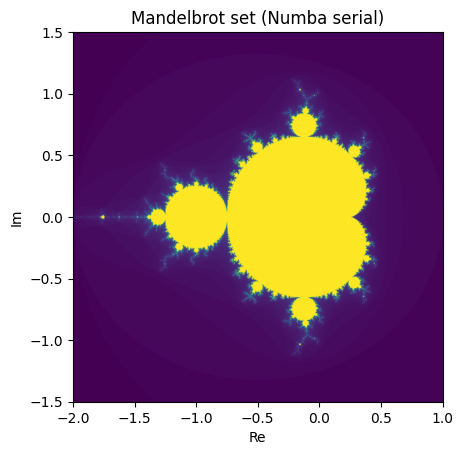

In [3]:
from mandelbrot import mandelbrot_serial
import matplotlib.pyplot as plt

grid_sizes = [1024]

max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5

width = grid_sizes[0]
height = grid_sizes[0]

warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_serial(*warm_args)

t0 = time.perf_counter()
numba_serial = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
t1 = time.perf_counter()

print(f"Runtime: {t1 - t0:.6f} s")

# plotting
plt.figure()
plt.imshow(numba_serial, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Numba serial)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.savefig("mandelbrot_numba_serial.png", dpi=150, bbox_inches="tight")
plt.show()

Runtime: 0.722121 s


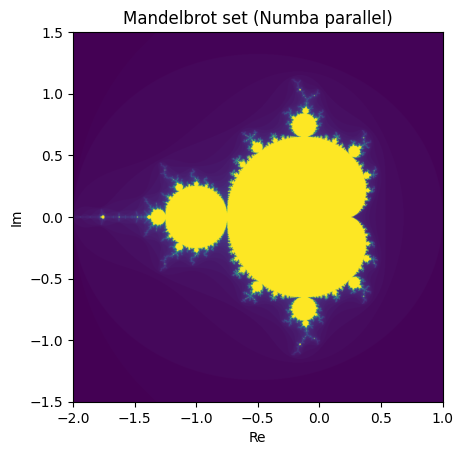

In [4]:
from mandelbrot import mandelbrot_parallel

width = 1024
height = 1024
max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5

# warmup
warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_serial(*warm_args)

t0 = time.perf_counter()
numba_parallel = mandelbrot_parallel(width, height, max_iter, xmin, xmax, ymin, ymax, 4)
t1 = time.perf_counter()

print(f"Runtime: {t1 - t0:.6f} s")

# plotting
plt.figure()
plt.imshow(numba_parallel, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Numba parallel)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.savefig("mandelbrot_numba_parallel.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
import numpy as np
serial_img = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
parallel_img = mandelbrot_parallel(width, height, max_iter, xmin, xmax, ymin, ymax, 4)

print(np.array_equal(serial_img, parallel_img))

True


In [6]:
import os
import time
import statistics
import multiprocessing as mp

from mandelbrot import mandelbrot_serial, build_chunks, _worker_func


def time_serial_3x(width, height, max_iter, xmin, xmax, ymin, ymax):
    times = []

    for _ in range(3):
        t0 = time.perf_counter()
        img = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return statistics.median(times), img


def time_parallel_3x(width, height, max_iter, xmin, xmax, ymin, ymax, n_workers):
    times = []
    last_img = None

    chunks = build_chunks(width, height, max_iter, xmin, xmax, ymin, ymax, n_workers)

    with mp.Pool(processes=n_workers) as pool:
        # untimed warm-up: triggers Numba compilation in worker processes
        warm_parts = pool.map(_worker_func, chunks)
        last_img = np.vstack(warm_parts)

        for _ in range(3):
            t0 = time.perf_counter()
            parts = pool.map(_worker_func, chunks)
            img = np.vstack(parts)
            t1 = time.perf_counter()

            times.append(t1 - t0)
            last_img = img

    return statistics.median(times), last_img


if __name__ == "__main__":
    width = 1024
    height = 1024
    max_iter = 100
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5

    # M1 warm-up in main process
    mandelbrot_serial(256, 256, max_iter, xmin, xmax, ymin, ymax)

    # Serial baseline: 3 runs, median
    t_serial, img_serial = time_serial_3x(width, height, max_iter, xmin, xmax, ymin, ymax)
    print(f"Serial median time: {t_serial:.6f} s")

    max_workers = os.cpu_count()

    for n_workers in range(1, max_workers + 1):
        t_parallel, img_parallel = time_parallel_3x(
            width, height, max_iter, xmin, xmax, ymin, ymax, n_workers
        )

        speedup = t_serial / t_parallel
        efficiency = speedup / n_workers
        matches = np.array_equal(img_serial, img_parallel)

        print(
            f"{n_workers:2d} workers | "
            f"tp = {t_parallel:.6f} s | "
            f"Sp = {speedup:.3f} | "
            f"Ep = {efficiency:.3f} | "
            f"match = {matches}"
        )

Serial median time: 0.051954 s
 1 workers | tp = 0.061714 s | Sp = 0.842 | Ep = 0.842 | match = True
 2 workers | tp = 0.032794 s | Sp = 1.584 | Ep = 0.792 | match = True
 3 workers | tp = 0.043426 s | Sp = 1.196 | Ep = 0.399 | match = True
 4 workers | tp = 0.028089 s | Sp = 1.850 | Ep = 0.462 | match = True
 5 workers | tp = 0.029964 s | Sp = 1.734 | Ep = 0.347 | match = True
 6 workers | tp = 0.022837 s | Sp = 2.275 | Ep = 0.379 | match = True
 7 workers | tp = 0.023113 s | Sp = 2.248 | Ep = 0.321 | match = True
 8 workers | tp = 0.019402 s | Sp = 2.678 | Ep = 0.335 | match = True


In [8]:
results = []

for n_workers in range(1, max_workers + 1):
    t_parallel, img_parallel = time_parallel_3x(
        width, height, max_iter, xmin, xmax, ymin, ymax, n_workers
    )

    speedup = t_serial / t_parallel
    efficiency = speedup / n_workers
    matches = np.array_equal(img_serial, img_parallel)

    results.append((n_workers, t_parallel, speedup, efficiency, matches))

for n_workers, t_parallel, speedup, efficiency, matches in results:
    print(
        f"{n_workers:2d} workers | "
        f"tp = {t_parallel:.6f} s | "
        f"Sp = {speedup:.3f} | "
        f"Ep = {efficiency:.3f} | "
        f"match = {matches}"
    )

 1 workers | tp = 0.063464 s | Sp = 0.819 | Ep = 0.819 | match = True
 2 workers | tp = 0.037839 s | Sp = 1.373 | Ep = 0.687 | match = True
 3 workers | tp = 0.046534 s | Sp = 1.116 | Ep = 0.372 | match = True
 4 workers | tp = 0.029149 s | Sp = 1.782 | Ep = 0.446 | match = True
 5 workers | tp = 0.036229 s | Sp = 1.434 | Ep = 0.287 | match = True
 6 workers | tp = 0.024168 s | Sp = 2.150 | Ep = 0.358 | match = True
 7 workers | tp = 0.023817 s | Sp = 2.181 | Ep = 0.312 | match = True
 8 workers | tp = 0.020241 s | Sp = 2.567 | Ep = 0.321 | match = True


MP2 M1/M2: Mandelbrot refactored and parallel result verified?  
Yes, all true

MP2 M3: Benchmark complete — what speedup did you achieve?  
best observed speedup was about 2.6–2.7×